# Lecture 02, Notebook 07: Loss Functions and Genz Function Approximation

**Course:** Deep Learning for Solving and Estimating Dynamic Models in Economics and Finance  
**Script reference:** §1.3–1.4 (Loss functions and function approximation: Genz test functions)  
**Notebook role:** core  
**Author:** Simon Scheidegger  


In [ ]:
RUN_MODE = "smoke"  # one of: "smoke", "teaching", "production"
SEED = 0


# Genz Test Functions: Neural Network Approximation and Loss Functions

This notebook accompanies **Lecture 1 — Introduction to ML & Deep Learning**

**Goals:**
1. Implement three of the six Genz (1987) test functions.
2. Train neural networks to approximate them and visualise the results.
3. Study how the choice of loss function (MSE, MAE, Huber, quantile) affects
   robustness, especially in the presence of outliers.
4. Observe the curse of dimensionality when scaling from $d=2$ to $d=5$.

---

**Outline**

| Section | Topic |
|:--------|:------|
| 1 | The Genz test functions |
| 2 | Visualisation ($d{=}2$) |
| 3 | NN approximation with MSE loss |
| 4 | Convergence with training-set size |
| 5 | Beyond MSE — robust and asymmetric losses |
| 6 | Comparing losses on contaminated data |
| 7 | Quantile loss and asymmetric behaviour |
| 8 | Scaling to $d{=}5$: the curse of dimensionality |
| 9 | Discussion and takeaways |

In [1]:
# ----------------------------------------------------------------
# Imports and plot style
# ----------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from mpl_toolkits.mplot3d import Axes3D          # noqa: F401  (surface plots)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Consistent plot style (matches 02b notebook)
rcParams.update({
    "figure.dpi":       120,
    "font.size":        11,
    "axes.titlesize":   13,
    "axes.labelsize":   12,
    "legend.fontsize":  10,
    "xtick.labelsize":  10,
    "ytick.labelsize":  10,
    "font.family":      "serif",
    "mathtext.fontset":  "cm",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.25,
})

# Colour palette
C_MSE   = "#2a9d8f"   # teal
C_MAE   = "#e76f51"   # orange-red
C_HUBER = "#264653"   # dark blue
C_QUANT = "#e9c46a"   # gold
C_TRUE  = "#457b9d"   # steel blue
C_DATA  = "#6c757d"   # grey

np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow version: {tf.__version__}")

2026-02-13 13:25:52.726629: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770985552.746997  138442 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770985552.755022  138442 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-13 13:25:52.779820: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.18.0


---
## 1. The Genz (1987) Test Functions

Genz (1987) introduced six families of integrands on $[0,1]^d$ that are widely
used as benchmarks for numerical integration and function approximation.  Each
family is parameterised by vectors $\mathbf{c}$ (difficulty) and $\mathbf{w}$
(shift).

| # | Name | Formula |
|---|------|:--------|
| $f_1$ | **Oscillatory** | $\cos\!\bigl(2\pi w_1 + \sum_i c_i x_i\bigr)$ |
| $f_2$ | Product peak | $\prod_i (c_i^{-2} + (x_i - w_i)^2)^{-1}$ |
| $f_3$ | Corner peak | $(1 + \sum_i c_i x_i)^{-(d+1)}$ |
| $f_4$ | **Gaussian** | $\exp\!\bigl(-\sum_i c_i^2 (x_i - w_i)^2\bigr)$ |
| $f_5$ | **Continuous** | $\exp\!\bigl(-\sum_i c_i |x_i - w_i|\bigr)$ |
| $f_6$ | Discontinuous | $0$ if $x_1>w_1$ or $x_2>w_2$; else $\exp(\sum_i c_i x_i)$ |

We choose **$f_1$ (oscillatory), $f_4$ (Gaussian), $f_5$ (continuous)** for
pedagogical variety:
- $f_1$ is smooth and periodic — tests whether a NN captures oscillations.
- $f_4$ is smooth with a localised peak — resembles utility or density functions.
- $f_5$ has kinks from $|\cdot|$ — tests the ability to handle non-smoothness.

In [2]:
# ----------------------------------------------------------------
# Define the three Genz test functions (vectorised NumPy)
# ----------------------------------------------------------------

def genz_oscillatory(X, c, w):
    """f1: cos(2*pi*w[0] + sum_i c_i * x_i)"""
    return np.cos(2.0 * np.pi * w[0] + X @ c)


def genz_gaussian(X, c, w):
    """f4: exp(-sum_i c_i^2 * (x_i - w_i)^2)"""
    return np.exp(-np.sum(c**2 * (X - w)**2, axis=1))


def genz_continuous(X, c, w):
    """f5: exp(-sum_i c_i * |x_i - w_i|)"""
    return np.exp(-np.sum(c * np.abs(X - w), axis=1))


# Fixed parameters (drawn once, as in Genz 1987)
d = 2  # start with d=2 for visualisation
rng = np.random.RandomState(7)
c_param = rng.uniform(1.0, 3.0, size=d)
w_param = rng.uniform(0.2, 0.8, size=d)

print(f"d = {d}")
print(f"c = {c_param}")
print(f"w = {w_param}")

# Bundle for convenience
GENZ_FUNCS = {
    "Oscillatory ($f_1$)": genz_oscillatory,
    "Gaussian ($f_4$)":    genz_gaussian,
    "Continuous ($f_5$)":  genz_continuous,
}

d = 2
c = [1.15261658 2.55983758]
w = [0.46304554 0.63407911]


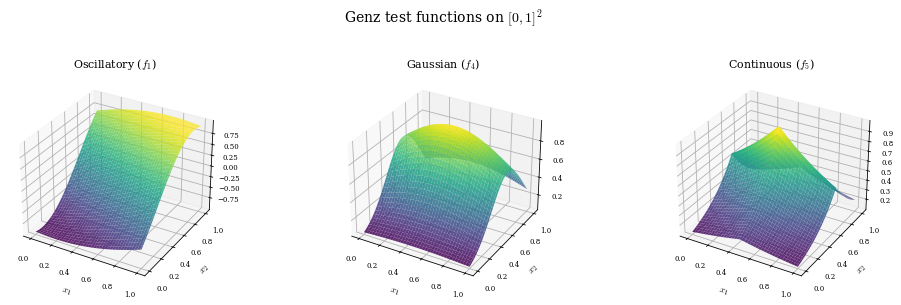

In [3]:
# ----------------------------------------------------------------
# Visualise the three Genz functions on [0,1]^2
# ----------------------------------------------------------------
grid_n = 80
t = np.linspace(0, 1, grid_n)
X1, X2 = np.meshgrid(t, t)
X_grid = np.column_stack([X1.ravel(), X2.ravel()])

fig, axes = plt.subplots(1, 3, figsize=(14, 4),
                         subplot_kw={"projection": "3d"})

for ax, (name, fn) in zip(axes, GENZ_FUNCS.items()):
    Z = fn(X_grid, c_param, w_param).reshape(grid_n, grid_n)
    ax.plot_surface(X1, X2, Z, cmap="viridis", alpha=0.85,
                    edgecolor="none", rcount=60, ccount=60)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("$x_1$", fontsize=9)
    ax.set_ylabel("$x_2$", fontsize=9)
    ax.tick_params(labelsize=7)

fig.suptitle("Genz test functions on $[0,1]^2$", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

In [4]:
# ----------------------------------------------------------------
# Generate training and test data
# ----------------------------------------------------------------
n_train_default = 1000
n_test = 2000

X_train = np.random.uniform(0, 1, size=(n_train_default, d)).astype(np.float32)
X_test  = np.random.uniform(0, 1, size=(n_test, d)).astype(np.float32)

# Compute targets for each function
y_train = {name: fn(X_train, c_param, w_param).astype(np.float32)
           for name, fn in GENZ_FUNCS.items()}
y_test  = {name: fn(X_test, c_param, w_param).astype(np.float32)
           for name, fn in GENZ_FUNCS.items()}

print(f"Training: {n_train_default} points,  Test: {n_test} points")
for name in GENZ_FUNCS:
    print(f"  {name}: y_train range [{y_train[name].min():.3f}, {y_train[name].max():.3f}]")

Training: 1000 points,  Test: 2000 points
  Oscillatory ($f_1$): y_train range [-1.000, 1.000]
  Gaussian ($f_4$): y_train range [0.060, 1.000]
  Continuous ($f_5$): y_train range [0.117, 0.990]


---
## 3. Build and Train a Neural Network (MSE Loss)

We use the same architecture for all three functions:
- **3 hidden layers, 64 units each, ReLU activation**
- Adam optimiser, learning rate 0.001
- MSE loss (the default regression loss)
- 200 epochs, batch size 64

In [5]:
# ----------------------------------------------------------------
# Helper: build a fresh model
# ----------------------------------------------------------------
def build_model(input_dim, loss="mse", lr=1e-3):
    """3-hidden-layer MLP with 64 units each."""
    model = keras.Sequential([
        layers.Dense(64, activation="relu", input_shape=(input_dim,)),
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(1),
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss=loss, metrics=["mae"])
    return model


# ----------------------------------------------------------------
# Train one model per Genz function (MSE loss)
# ----------------------------------------------------------------
mse_models = {}
mse_histories = {}

for name, fn in GENZ_FUNCS.items():
    print(f"\nTraining on {name} ...")
    m = build_model(d, loss="mse")
    h = m.fit(X_train, y_train[name],
              epochs=200, batch_size=64, verbose=0,
              validation_data=(X_test, y_test[name]))
    mse_models[name] = m
    mse_histories[name] = h

    # Quick evaluation
    pred = m.predict(X_test, verbose=0).flatten()
    err = np.abs(pred - y_test[name])
    print(f"  Mean abs error: {err.mean():.5f}   Max abs error: {err.max():.5f}")


Training on Oscillatory ($f_1$) ...


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-02-13 13:25:58.493013: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


  Mean abs error: 0.00916   Max abs error: 0.04774

Training on Gaussian ($f_4$) ...
  Mean abs error: 0.00413   Max abs error: 0.01605

Training on Continuous ($f_5$) ...
  Mean abs error: 0.00234   Max abs error: 0.01877


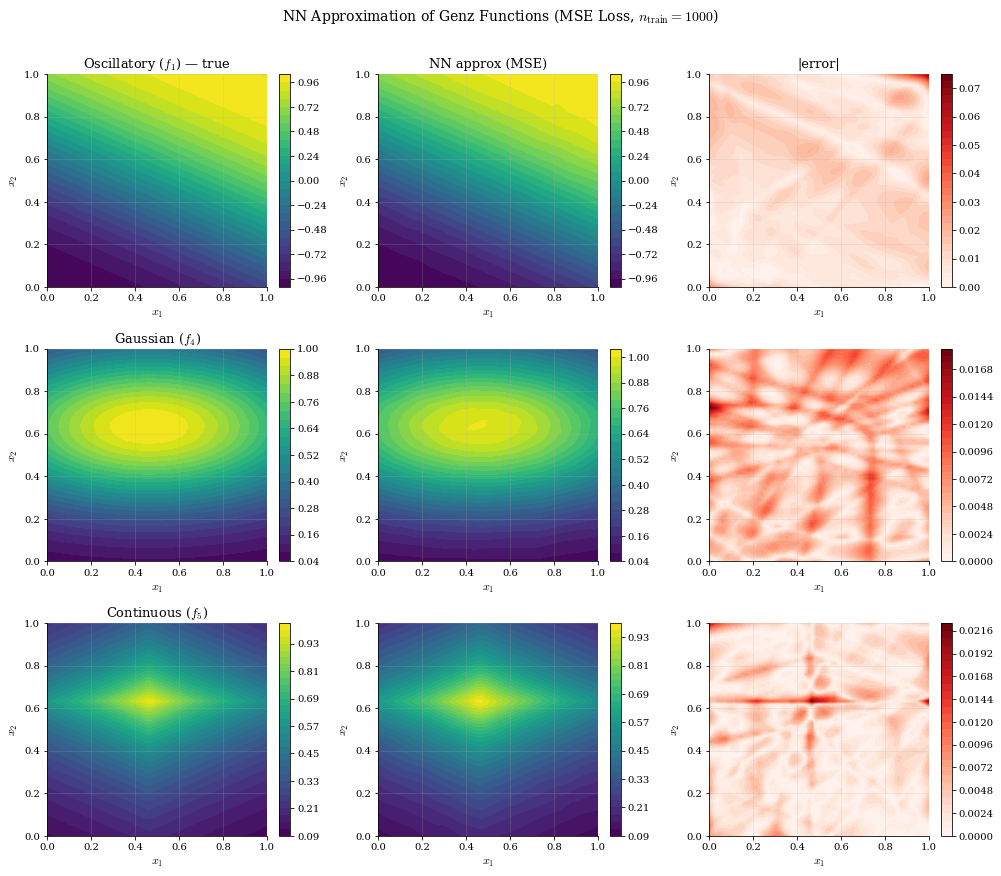

In [6]:
# ----------------------------------------------------------------
# Visualise: true surface, NN approximation, |error|
# ----------------------------------------------------------------
fig, axes = plt.subplots(3, 3, figsize=(14, 12))

for row, (name, fn) in enumerate(GENZ_FUNCS.items()):
    Z_true = fn(X_grid, c_param, w_param).reshape(grid_n, grid_n)
    Z_pred = mse_models[name].predict(X_grid.astype(np.float32),
                                       verbose=0).reshape(grid_n, grid_n)
    Z_err  = np.abs(Z_true - Z_pred)

    im0 = axes[row, 0].contourf(X1, X2, Z_true, levels=30, cmap="viridis")
    axes[row, 0].set_title(f"{name} — true" if row == 0 else name)
    plt.colorbar(im0, ax=axes[row, 0], fraction=0.046)

    im1 = axes[row, 1].contourf(X1, X2, Z_pred, levels=30, cmap="viridis")
    axes[row, 1].set_title("NN approx (MSE)" if row == 0 else "")
    plt.colorbar(im1, ax=axes[row, 1], fraction=0.046)

    im2 = axes[row, 2].contourf(X1, X2, Z_err, levels=30, cmap="Reds")
    axes[row, 2].set_title("|error|" if row == 0 else "")
    plt.colorbar(im2, ax=axes[row, 2], fraction=0.046)

    for c in range(3):
        axes[row, c].set_xlabel("$x_1$")
        axes[row, c].set_ylabel("$x_2$")

fig.suptitle("NN Approximation of Genz Functions (MSE Loss, $n_{\\mathrm{train}}=1000$)",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

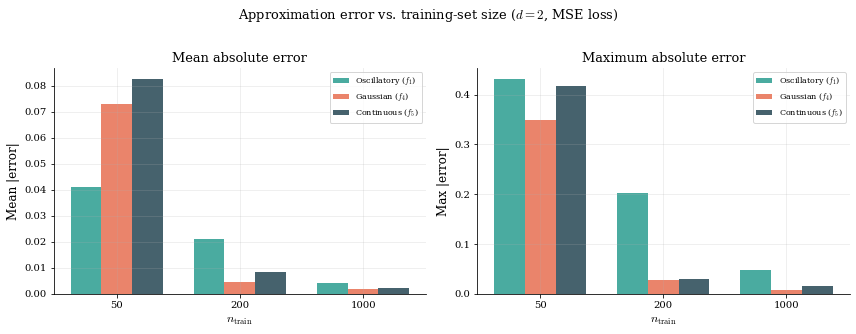

In [7]:
# ----------------------------------------------------------------
# Convergence with training-set size
# ----------------------------------------------------------------
n_train_values = [50, 200, 1000]
results = {name: {"mean_err": [], "max_err": []} for name in GENZ_FUNCS}

for n_tr in n_train_values:
    X_tr = np.random.uniform(0, 1, size=(n_tr, d)).astype(np.float32)
    for name, fn in GENZ_FUNCS.items():
        y_tr = fn(X_tr, c_param, w_param).astype(np.float32)
        m = build_model(d, loss="mse")
        m.fit(X_tr, y_tr, epochs=200, batch_size=min(64, n_tr), verbose=0)
        pred = m.predict(X_test, verbose=0).flatten()
        err = np.abs(pred - y_test[name])
        results[name]["mean_err"].append(err.mean())
        results[name]["max_err"].append(err.max())

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
x_pos = np.arange(len(n_train_values))
width = 0.25
colours = [C_MSE, C_MAE, C_HUBER]

for metric_idx, metric in enumerate(["mean_err", "max_err"]):
    ax = axes[metric_idx]
    for i, (name, col) in enumerate(zip(GENZ_FUNCS, colours)):
        vals = results[name][metric]
        ax.bar(x_pos + i * width, vals, width, label=name, color=col, alpha=0.85)
    ax.set_xticks(x_pos + width)
    ax.set_xticklabels([str(n) for n in n_train_values])
    ax.set_xlabel("$n_{\\mathrm{train}}$")
    ax.set_ylabel("Mean |error|" if metric_idx == 0 else "Max |error|")
    ax.set_title("Mean absolute error" if metric_idx == 0 else "Maximum absolute error")
    ax.legend(fontsize=8)

fig.suptitle("Approximation error vs. training-set size ($d=2$, MSE loss)",
             fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

---
## 5. Beyond MSE: Robust and Asymmetric Losses

MSE is the default regression loss, but it has weaknesses:
- **Sensitive to outliers:** a single large residual dominates the gradient.
- **Symmetric:** over- and under-predictions are penalised equally.

In economics and finance, we often care about **tail risk** — getting the
worst-case predictions right matters more than small errors in the bulk.

### Alternative loss functions

| Loss | Formula | When it helps |
|:-----|:--------|:--------------|
| **MSE** | $\frac{1}{n}\sum(y - \hat{y})^2$ | Baseline; optimal under Gaussian noise |
| **MAE** (L1) | $\frac{1}{n}\sum|y - \hat{y}|$ | Robust to outliers; median regression |
| **Huber($\delta$)** | Quadratic for $|e|<\delta$, linear otherwise | Best of both: smooth + robust |
| **Quantile($\tau$)** | $\rho_\tau(e) = e\,(\tau - \mathbf{1}_{e<0})$ | Asymmetric risk; penalises under-prediction at quantile $\tau$ |

In [8]:
# ----------------------------------------------------------------
# Define custom Keras losses
# ----------------------------------------------------------------

def quantile_loss(tau):
    """Pinball / quantile loss for a given quantile level tau."""
    def loss_fn(y_true, y_pred):
        e = y_true - tf.squeeze(y_pred)
        return tf.reduce_mean(tf.maximum(tau * e, (tau - 1.0) * e))
    loss_fn.__name__ = f"quantile_{tau}"
    return loss_fn


# Built-in losses we will use:
#   keras.losses.MeanSquaredError()           — MSE
#   keras.losses.MeanAbsoluteError()          — MAE
#   keras.losses.Huber(delta=1.0)             — Huber
#   quantile_loss(0.9)                        — Quantile (tau=0.9)

LOSSES = {
    "MSE":             "mse",
    "MAE":             "mae",
    "Huber ($\\delta$=1)": keras.losses.Huber(delta=1.0),
    "Quantile ($\\tau$=0.9)": quantile_loss(0.9),
}

print("Losses defined:", list(LOSSES.keys()))

Losses defined: ['MSE', 'MAE', 'Huber ($\\delta$=1)', 'Quantile ($\\tau$=0.9)']


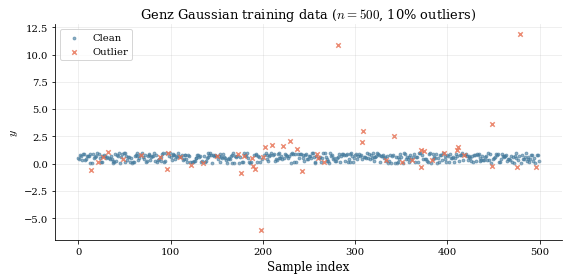

Clean range:  [0.063, 0.999]
Contaminated: [-6.073, 11.861]


In [9]:
# ----------------------------------------------------------------
# Contaminate training data (Genz Gaussian, f4)
# ----------------------------------------------------------------
target_name = "Gaussian ($f_4$)"
n_cont = 500
outlier_frac = 0.10

X_cont = np.random.uniform(0, 1, size=(n_cont, d)).astype(np.float32)
y_clean = genz_gaussian(X_cont, c_param, w_param).astype(np.float32)

# Add heavy-tailed noise to 10% of points
n_outliers = int(outlier_frac * n_cont)
outlier_idx = np.random.choice(n_cont, n_outliers, replace=False)
y_cont = y_clean.copy()
y_cont[outlier_idx] += np.random.standard_cauchy(n_outliers).astype(np.float32) * 0.5

# Scatter plot: clean vs contaminated
fig, ax = plt.subplots(figsize=(8, 4))
mask = np.zeros(n_cont, dtype=bool)
mask[outlier_idx] = True
ax.scatter(np.arange(n_cont)[~mask], y_cont[~mask], s=8, color=C_TRUE,
           label="Clean", alpha=0.6)
ax.scatter(np.arange(n_cont)[mask], y_cont[mask], s=20, color=C_MAE,
           label="Outlier", alpha=0.8, marker="x")
ax.set_xlabel("Sample index")
ax.set_ylabel("$y$")
ax.set_title(f"Genz Gaussian training data ($n={n_cont}$, {outlier_frac:.0%} outliers)")
ax.legend()
fig.tight_layout()
plt.show()

print(f"Clean range:  [{y_clean.min():.3f}, {y_clean.max():.3f}]")
print(f"Contaminated: [{y_cont.min():.3f}, {y_cont.max():.3f}]")

In [10]:
# ----------------------------------------------------------------
# Train with 4 different losses on the same contaminated data
# ----------------------------------------------------------------
loss_models = {}
loss_histories = {}

for loss_name, loss_fn in LOSSES.items():
    print(f"Training with {loss_name} ...")
    m = build_model(d, loss=loss_fn)
    h = m.fit(X_cont, y_cont, epochs=200, batch_size=64, verbose=0)
    loss_models[loss_name] = m
    loss_histories[loss_name] = h

print("Done.")

Training with MSE ...


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training with MAE ...
Training with Huber ($\delta$=1) ...
Training with Quantile ($\tau$=0.9) ...
Done.


Loss                    Mean |err|   Max |err|  Median |err|
----------------------------------------------------------
MSE                        0.09389     0.42735       0.06842
MAE                        0.00492     0.02705       0.00393
Huber ($\delta$=1)         0.04091     0.26169       0.02849
Quantile ($\tau$=0.9)      0.40328     0.94374       0.37518


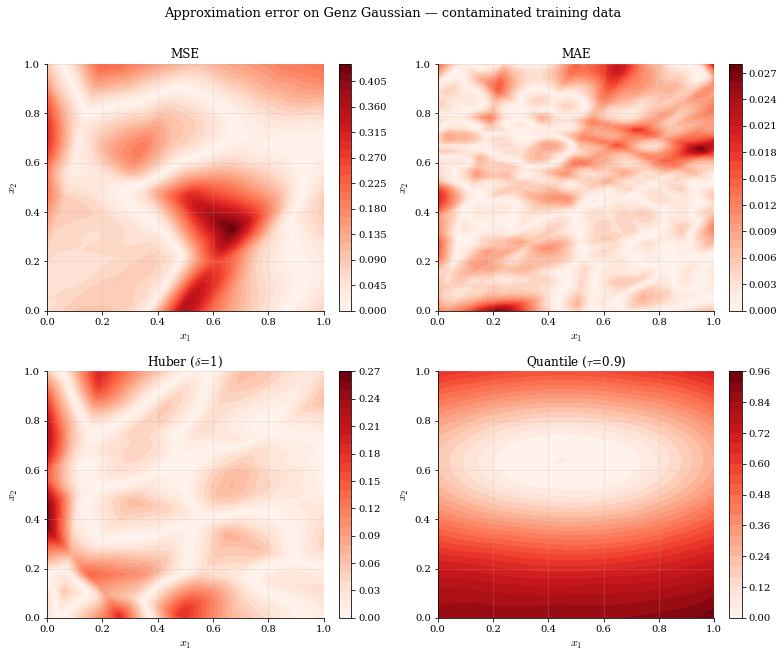

In [11]:
# ----------------------------------------------------------------
# Compare: |error| heatmaps for each loss
# ----------------------------------------------------------------
y_test_gauss = genz_gaussian(X_grid.astype(np.float32), c_param, w_param)

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes_flat = axes.flatten()

print(f"{'Loss':<22s}  {'Mean |err|':>10s}  {'Max |err|':>10s}  {'Median |err|':>12s}")
print("-" * 58)

for ax, (loss_name, m) in zip(axes_flat, loss_models.items()):
    pred = m.predict(X_grid.astype(np.float32), verbose=0).flatten()
    err = np.abs(y_test_gauss - pred).reshape(grid_n, grid_n)
    im = ax.contourf(X1, X2, err, levels=30, cmap="Reds")
    ax.set_title(loss_name, fontsize=12)
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    plt.colorbar(im, ax=ax, fraction=0.046)

    err_flat = err.ravel()
    print(f"{loss_name:<22s}  {err_flat.mean():10.5f}  {err_flat.max():10.5f}  {np.median(err_flat):12.5f}")

fig.suptitle("Approximation error on Genz Gaussian — contaminated training data",
             fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

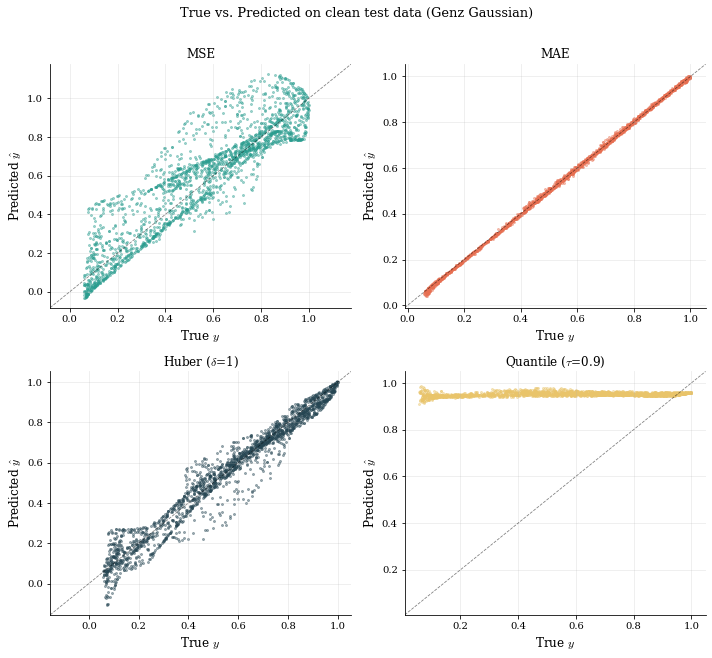

In [12]:
# ----------------------------------------------------------------
# Scatter: true y vs predicted y for each loss
# ----------------------------------------------------------------
y_test_gauss_pts = genz_gaussian(X_test, c_param, w_param).astype(np.float32)

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
colours_loss = [C_MSE, C_MAE, C_HUBER, C_QUANT]

for ax, (loss_name, m), col in zip(axes.flatten(), loss_models.items(), colours_loss):
    pred = m.predict(X_test, verbose=0).flatten()
    ax.scatter(y_test_gauss_pts, pred, s=4, alpha=0.4, color=col)
    lims = [min(y_test_gauss_pts.min(), pred.min()) - 0.05,
            max(y_test_gauss_pts.max(), pred.max()) + 0.05]
    ax.plot(lims, lims, "k--", lw=0.8, alpha=0.5)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel("True $y$")
    ax.set_ylabel("Predicted $\\hat{y}$")
    ax.set_title(loss_name, fontsize=12)

fig.suptitle("True vs. Predicted on clean test data (Genz Gaussian)",
             fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

---
## 7. Quantile Loss: Asymmetric Behaviour

The quantile (pinball) loss penalises under-predictions and over-predictions
differently.  At $\tau = 0.1$ the model targets the **10th percentile**
(conservative, low prediction); at $\tau = 0.9$ it targets the **90th
percentile** (aggressive, high prediction).

**Economic motivation:** In risk management, we care about Value-at-Risk (VaR)
— the loss that is exceeded only $\alpha\%$ of the time.  Training a network
with quantile loss at $\tau = 0.05$ produces a VaR estimator directly.

Training quantile model (tau=0.1) ...
Training quantile model (tau=0.5) ...
Training quantile model (tau=0.9) ...


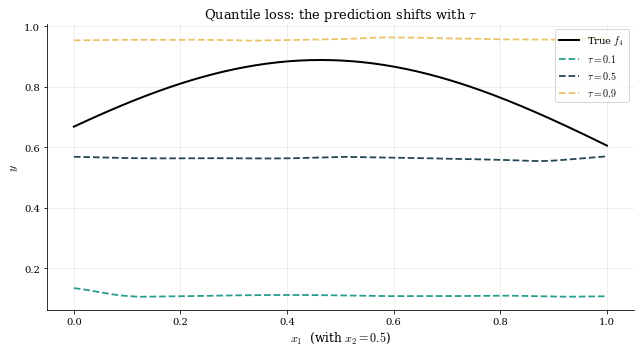


Note: tau=0.1 predicts lower (conservative), tau=0.9 predicts higher (aggressive).


In [13]:
# ----------------------------------------------------------------
# Train with quantile loss at tau = 0.1, 0.5, 0.9 (clean data)
# ----------------------------------------------------------------
taus = [0.1, 0.5, 0.9]
q_models = {}

# Use clean Gaussian data with some Gaussian noise for this demo
n_q = 1000
X_q = np.random.uniform(0, 1, size=(n_q, d)).astype(np.float32)
y_q_clean = genz_gaussian(X_q, c_param, w_param).astype(np.float32)
y_q_noisy = y_q_clean + 0.15 * np.random.randn(n_q).astype(np.float32)

for tau in taus:
    print(f"Training quantile model (tau={tau}) ...")
    m = build_model(d, loss=quantile_loss(tau))
    m.fit(X_q, y_q_noisy, epochs=200, batch_size=64, verbose=0)
    q_models[tau] = m

# Predict on a slice x2 = 0.5 for visualisation
x1_line = np.linspace(0, 1, 200).astype(np.float32)
X_line = np.column_stack([x1_line, 0.5 * np.ones_like(x1_line)])
y_true_line = genz_gaussian(X_line, c_param, w_param)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x1_line, y_true_line, "k-", lw=2, label="True $f_4$")

q_colours = {0.1: C_MSE, 0.5: C_HUBER, 0.9: C_QUANT}
for tau in taus:
    pred = q_models[tau].predict(X_line, verbose=0).flatten()
    ax.plot(x1_line, pred, lw=1.8, ls="--",
            color=q_colours[tau], label=f"$\\tau={tau}$")

ax.set_xlabel("$x_1$  (with $x_2 = 0.5$)")
ax.set_ylabel("$y$")
ax.set_title("Quantile loss: the prediction shifts with $\\tau$")
ax.legend()
fig.tight_layout()
plt.show()

print("\nNote: tau=0.1 predicts lower (conservative), "
      "tau=0.9 predicts higher (aggressive).")

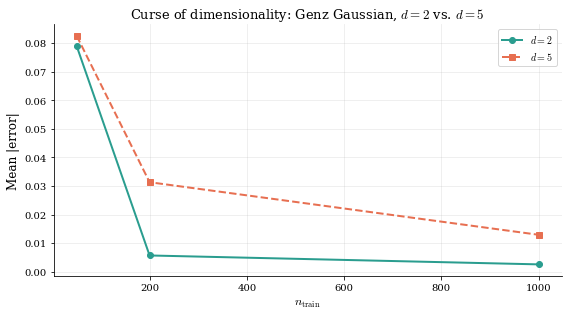


Mean absolute errors:
n_train          d=2       d=5
50           0.07898   0.08255
200          0.00566   0.03131
1000         0.00255   0.01291


In [15]:
# ----------------------------------------------------------------
# Scaling to d=5: the curse of dimensionality
# ----------------------------------------------------------------
d5 = 5
rng5 = np.random.RandomState(7)
c5 = rng5.uniform(1.0, 3.0, size=d5)
w5 = rng5.uniform(0.2, 0.8, size=d5)

n_test5 = 2000
X_test5 = np.random.uniform(0, 1, size=(n_test5, d5)).astype(np.float32)
y_test5 = genz_gaussian(X_test5, c5, w5).astype(np.float32)

n_train_sweep = [50, 200, 1000]
errors_d2 = []
errors_d5 = []

for n_tr in n_train_sweep:
    # d=2
    X_tr2 = np.random.uniform(0, 1, size=(n_tr, d)).astype(np.float32)
    y_tr2 = genz_gaussian(X_tr2, c_param, w_param).astype(np.float32)
    m2 = build_model(d, loss="mse")
    m2.fit(X_tr2, y_tr2, epochs=200, batch_size=min(64, n_tr), verbose=0)
    pred2 = m2.predict(X_test, verbose=0).flatten()
    errors_d2.append(np.abs(pred2 - y_test[target_name]).mean())

    # d=5
    X_tr5 = np.random.uniform(0, 1, size=(n_tr, d5)).astype(np.float32)
    y_tr5 = genz_gaussian(X_tr5, c5, w5).astype(np.float32)
    m5 = build_model(d5, loss="mse")
    m5.fit(X_tr5, y_tr5, epochs=200, batch_size=min(64, n_tr), verbose=0)
    pred5 = m5.predict(X_test5, verbose=0).flatten()
    errors_d5.append(np.abs(pred5 - y_test5).mean())

# Plot
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(n_train_sweep, errors_d2, "o-", lw=2, color=C_MSE, label="$d=2$")
ax.plot(n_train_sweep, errors_d5, "s--", lw=2, color=C_MAE, label="$d=5$")
ax.set_xlabel("$n_{\\mathrm{train}}$")
ax.set_ylabel("Mean |error|")
ax.set_title("Curse of dimensionality: Genz Gaussian, $d=2$ vs. $d=5$")
ax.legend()
fig.tight_layout()
plt.show()

print("\nMean absolute errors:")
print(f"{'n_train':<10s}  {'d=2':>8s}  {'d=5':>8s}")
for n_tr, e2, e5 in zip(n_train_sweep, errors_d2, errors_d5):
    print(f"{n_tr:<10d}  {e2:8.5f}  {e5:8.5f}")

---
## 9. Discussion and Takeaways

1. **Neural networks are effective function approximators** — even a modest
   3-layer MLP with 64 units can capture oscillations, peaks, and kinks in
   the Genz test functions.

2. **MSE is not always the best loss:**
   - When training data contains outliers, MSE is distorted because it
     penalises large residuals quadratically.
   - **MAE** and **Huber** are more robust; Huber combines smoothness
     (easier optimisation) with robustness (linear tails).

3. **Quantile loss enables asymmetric risk management:**
   - By choosing $\tau < 0.5$ or $\tau > 0.5$, the model shifts its
     predictions to target a specific quantile of the conditional
     distribution.
   - This is directly useful for **Value-at-Risk (VaR)** estimation and
     other tail-risk applications in finance.

4. **The curse of dimensionality is real:**
   - Approximation error grows significantly as $d$ increases for a
     fixed number of training points.
   - This motivates the use of structured models (e.g., physics-informed
     networks, deep equilibrium nets) that exploit problem structure.

### References

- A. Genz (1987). *Testing multidimensional integration routines.*
  In: Tools, Methods and Languages for Scientific and Engineering Computation,
  Elsevier, pp. 81–94.
- P. Huber (1964). *Robust estimation of a location parameter.*
  Annals of Mathematical Statistics 35(1), 73–101.
- R. Koenker & G. Bassett (1978). *Regression quantiles.*
  Econometrica 46(1), 33–50.